# Long Pipe Flow Analysis and Visualization

This notebook provides comprehensive analysis of long pipe simulation configurations, including:
- Data availability checking (.npz files)
- Wall Shear Stress (WSS) analysis and visualization
- Velocity profile analysis across different cross-sections
- Comparative analysis between different simulation configurations
- Flow development characterization in extended pipe geometries

In [20]:
# Import required libraries
import numpy as np
import os
import glob
from pathlib import Path
import pandas as pd

## Find Long Pipe Configurations

Identify all long pipe simulation configurations in the results directory.

In [21]:
# Define the base directory where the simulation results are located
base_dir = Path.cwd()
pipe_results_dir = base_dir / '../results/pipe_flow'

print(f"Searching in: {pipe_results_dir}")
print(f"Directory exists: {pipe_results_dir.exists()}")

# Find all long pipe configurations
long_pipe_configs = []
if pipe_results_dir.exists():
    for config_dir in pipe_results_dir.iterdir():
        if config_dir.is_dir() and 'long' in config_dir.name:
            long_pipe_configs.append(config_dir)

print(f"\nFound {len(long_pipe_configs)} long pipe configurations:")
for config in long_pipe_configs:
    print(f"  - {config.name}")

Searching in: /home/abdua786/code/uni/3/dissertation/dissertation/visualisation_src/../results/pipe_flow
Directory exists: True

Found 3 long pipe configurations:
  - zh_nnbgk_uniform_long
  - zh_nnbgk_blunted_long
  - zh_nnbgk_poiseuille_long


## Check for NPZ Files in Each Configuration

For each long pipe configuration, check for .npz files in various subdirectories.

In [22]:
def check_npz_files(config_dir):
    """Check for .npz files in a configuration directory and its subdirectories"""
    npz_files = []
    
    # Search recursively for .npz files
    for npz_file in config_dir.rglob('*.npz'):
        npz_files.append(npz_file)
    
    return npz_files

# Check each long pipe configuration
results = {}

for config in long_pipe_configs:
    print(f"\n{'='*60}")
    print(f"Checking configuration: {config.name}")
    print(f"{'='*60}")
    
    # Check directory structure
    subdirs = [d for d in config.iterdir() if d.is_dir()]
    print(f"Subdirectories: {[d.name for d in subdirs]}")
    
    # Check for .npz files
    npz_files = check_npz_files(config)
    
    if npz_files:
        print(f"✅ Found {len(npz_files)} .npz files:")
        for npz_file in npz_files:
            rel_path = npz_file.relative_to(config)
            print(f"   - {rel_path}")
    else:
        print(f"❌ No .npz files found")
    
    # Check for processed_data directory specifically
    processed_data_dir = config / 'processed_data'
    if processed_data_dir.exists():
        print(f"📁 Found processed_data directory")
        processed_npz = check_npz_files(processed_data_dir)
        if processed_npz:
            print(f"   Contains {len(processed_npz)} .npz files:")
            for npz_file in processed_npz:
                rel_path = npz_file.relative_to(processed_data_dir)
                print(f"   - {rel_path}")
    else:
        print(f"📁 No processed_data directory found")
    
    # Store results
    results[config.name] = {
        'config_path': str(config),
        'npz_count': len(npz_files),
        'npz_files': [str(f.relative_to(config)) for f in npz_files],
        'has_processed_data': processed_data_dir.exists(),
        'subdirectories': [d.name for d in subdirs]
    }


Checking configuration: zh_nnbgk_uniform_long
Subdirectories: ['processed_data', 'parameters', 'images', 'vtk']
✅ Found 12 .npz files:
   - processed_data/raw_fields/frame_mapping.npz
   - processed_data/raw_fields/outlet_mask.npz
   - processed_data/raw_fields/inlet_mask.npz
   - processed_data/raw_fields/u_magnitude.npz
   - processed_data/raw_fields/wss_y.npz
   - processed_data/raw_fields/dimensions.npz
   - processed_data/raw_fields/u_x.npz
   - processed_data/raw_fields/u_y.npz
   - processed_data/raw_fields/wss_x.npz
   - processed_data/raw_fields/wss_magnitude.npz
   - processed_data/raw_fields/wall_mask.npz
   - processed_data/raw_fields/rho.npz
📁 Found processed_data directory
   Contains 12 .npz files:
   - raw_fields/frame_mapping.npz
   - raw_fields/outlet_mask.npz
   - raw_fields/inlet_mask.npz
   - raw_fields/u_magnitude.npz
   - raw_fields/wss_y.npz
   - raw_fields/dimensions.npz
   - raw_fields/u_x.npz
   - raw_fields/u_y.npz
   - raw_fields/wss_x.npz
   - raw_fields/

## Summary Report

Generate a summary report of all findings.

In [23]:
# Create summary DataFrame
summary_data = []
for config_name, data in results.items():
    summary_data.append({
        'Configuration': config_name,
        'NPZ Files Found': data['npz_count'],
        'Has Processed Data': data['has_processed_data'],
        'Subdirectories': ', '.join(data['subdirectories'])
    })

summary_df = pd.DataFrame(summary_data)
print("SUMMARY REPORT")
print("="*80)
print(summary_df.to_string(index=False))

print(f"\nTotal long pipe configurations: {len(long_pipe_configs)}")
print(f"Configurations with .npz files: {sum(1 for data in results.values() if data['npz_count'] > 0)}")
print(f"Configurations with processed_data directory: {sum(1 for data in results.values() if data['has_processed_data'])}")

# Show configurations with no data
no_data_configs = [name for name, data in results.items() if data['npz_count'] == 0]
if no_data_configs:
    print(f"\nConfigurations WITHOUT .npz files:")
    for config in no_data_configs:
        print(f"  - {config}")

SUMMARY REPORT
           Configuration  NPZ Files Found  Has Processed Data                          Subdirectories
   zh_nnbgk_uniform_long               12                True processed_data, parameters, images, vtk
   zh_nnbgk_blunted_long               12                True processed_data, parameters, images, vtk
zh_nnbgk_poiseuille_long               12                True processed_data, parameters, images, vtk

Total long pipe configurations: 3
Configurations with .npz files: 3
Configurations with processed_data directory: 3


## Check Alternative Data Formats

Check for other data formats that might be present (VTK files, parameter files, etc.).

In [24]:
# Check for other file types in each configuration
file_type_summary = {}

for config in long_pipe_configs:
    config_name = config.name
    file_types = {}
    
    # Count different file types
    for file_pattern in ['*.vtk', '*.json', '*.png', '*.txt', '*.log']:
        files = list(config.rglob(file_pattern))
        if files:
            file_types[file_pattern.replace('*', '')] = len(files)
    
    file_type_summary[config_name] = file_types
    
    print(f"\n{config_name}:")
    if file_types:
        for file_type, count in file_types.items():
            print(f"  {file_type}: {count} files")
    else:
        print("  No common file types found")

print(f"\n{'='*80}")
print("FILE TYPE SUMMARY ACROSS ALL LONG PIPE CONFIGURATIONS")
print(f"{'='*80}")

# Aggregate file type counts
all_file_types = set()
for config_files in file_type_summary.values():
    all_file_types.update(config_files.keys())

for file_type in sorted(all_file_types):
    total_count = sum(config_files.get(file_type, 0) for config_files in file_type_summary.values())
    configs_with_type = sum(1 for config_files in file_type_summary.values() if file_type in config_files)
    print(f"{file_type}: {total_count} files across {configs_with_type} configurations")


zh_nnbgk_uniform_long:
  .vtk: 101 files
  .json: 1 files
  .png: 303 files
  .txt: 1 files

zh_nnbgk_blunted_long:
  .vtk: 101 files
  .json: 1 files
  .png: 303 files
  .txt: 1 files

zh_nnbgk_poiseuille_long:
  .vtk: 101 files
  .json: 1 files
  .png: 303 files
  .txt: 1 files

FILE TYPE SUMMARY ACROSS ALL LONG PIPE CONFIGURATIONS
.json: 3 files across 3 configurations
.png: 909 files across 3 configurations
.txt: 3 files across 3 configurations
.vtk: 303 files across 3 configurations


## WSS Visualization for Long Pipe Configurations

Load and visualize Wall Shear Stress (WSS) data for each long pipe configuration that has processed data.

In [25]:
# Additional imports for WSS visualization
import matplotlib.pyplot as plt
import json
import time
import sys

In [26]:
# Function to load velocity data
def load_velocity_data(sim_folder, sim_name):
    data_dir = sim_folder / 'processed_data' / 'raw_fields'
    if not data_dir.exists():
        print(f"Data directory not found for {sim_name}: {data_dir}")
        return None
    
    try:
        print(f"\nLoading velocity data for {sim_name}...")
        # Load frame mapping
        frame_mapping_file = data_dir / 'frame_mapping.npz'
        if frame_mapping_file.exists():
            frame_mapping = np.load(frame_mapping_file)
            frame_numbers = frame_mapping['frame_numbers']
            frame_indices = frame_mapping['frame_indices']
            print(f"Found {len(frame_numbers)} frames, range: {min(frame_numbers)} to {max(frame_numbers)}")
        else:
            print(f"Frame mapping file not found: {frame_mapping_file}")
            return None
        
        # Load velocity components
        start_time = time.time()
        
        # Load u_magnitude
        u_magnitude_file = data_dir / 'u_magnitude.npz'
        if u_magnitude_file.exists():
            u_magnitude_data = np.load(u_magnitude_file)['data']
            print(f"Loaded u_magnitude data with shape: {u_magnitude_data.shape}")
        else:
            print(f"u_magnitude data file not found: {u_magnitude_file}")
            u_magnitude_data = None
        
        load_time = time.time() - start_time
        print(f"Data loaded in {load_time:.2f} seconds")
        
        return {
            'frame_numbers': frame_numbers,
            'frame_indices': frame_indices,
            'u_magnitude': u_magnitude_data
        }
    
    except Exception as e:
        print(f"Error loading velocity data for {sim_name}: {e}")
        return None

# Function to load WSS data
def load_wss_data(sim_folder, sim_name):
    data_dir = sim_folder / 'processed_data' / 'raw_fields'
    if not data_dir.exists():
        print(f"Data directory not found for {sim_name}: {data_dir}")
        return None
    
    try:
        print(f"\nLoading WSS data for {sim_name}...")
        start_time = time.time()
        
        # Load WSS magnitude
        wss_magnitude_file = data_dir / 'wss_magnitude.npz'
        if wss_magnitude_file.exists():
            wss_magnitude_data = np.load(wss_magnitude_file)['data']
            print(f"Loaded wss_magnitude data with shape: {wss_magnitude_data.shape}")
        else:
            print(f"wss_magnitude data file not found: {wss_magnitude_file}")
            wss_magnitude_data = None
        
        load_time = time.time() - start_time
        print(f"WSS data loaded in {load_time:.2f} seconds")
        
        return {
            'wss_magnitude': wss_magnitude_data
        }
    
    except Exception as e:
        print(f"Error loading WSS data for {sim_name}: {e}")
        return None

# Function to load simulation parameters
def load_params(param_file):
    try:
        with open(param_file, 'r') as f:
            params = json.load(f)
        print(f"Successfully loaded parameters from {param_file}")
        return params
    except Exception as e:
        print(f"Error loading parameters from {param_file}: {e}")
        return None

In [27]:
def analyze_pipe_wss(velocity_data, wss_data, params, time=1.0, config_name="Unknown"):
    """Analyze wall shear stress distribution along the pipe walls"""
    if velocity_data is None or wss_data is None:
        print(f"Missing velocity or WSS data for {config_name}")
        return
    
    # Extract frame data
    frame_numbers = velocity_data.get('frame_numbers')
    u_magnitude = velocity_data.get('u_magnitude')
    wss_magnitude = wss_data.get('wss_magnitude')
    
    if frame_numbers is None or u_magnitude is None or wss_magnitude is None:
        print(f"Missing required data components for {config_name}")
        return
    
    # Get simulation parameters
    if params is not None:
        dt = params['input_parameters'].get('dt', 1e-5)
        dx = params['input_parameters'].get('dx', 2e-5)
        fps = params['input_parameters'].get('fps', 100)
        vessel_centre_lu = params['input_parameters'].get('vessel_centre_lu', u_magnitude[0].shape[0] // 2)
    else:
        # Default values
        dt = 1e-5
        dx = 2e-5
        fps = 100
        vessel_centre_lu = u_magnitude[0].shape[0] // 2
    
    # Convert time to frame index
    frame_idx = int(time * fps)
    
    # Ensure frame_idx is valid
    if frame_idx >= len(u_magnitude):
        frame_idx = len(u_magnitude) - 1
        print(f"Time out of range for {config_name}. Using last available time {frame_numbers[frame_idx] * dt:.2f}s instead.")
    
    # Get data for the specified time
    frame_num = frame_numbers[frame_idx]
    frame_u_mag = u_magnitude[frame_idx]
    frame_wss_mag = wss_magnitude[frame_idx]
    
    # Get dimensions
    ny, nx = frame_u_mag.shape
    
    # Find the upper and lower walls by detecting non-zero WSS values
    upper_wall_indices = []
    lower_wall_indices = []
    
    for x in range(nx):
        # Find wall cells in this column (non-zero WSS)
        wall_indices = np.where(frame_wss_mag[:, x] > 0)[0]
        
        if len(wall_indices) > 0:
            # Separate upper and lower walls based on vessel center
            upper_indices = wall_indices[wall_indices > vessel_centre_lu]
            lower_indices = wall_indices[wall_indices < vessel_centre_lu]
            
            # Take the innermost wall cells (closest to the lumen)
            if len(upper_indices) > 0:
                upper_wall_indices.append((x, upper_indices.min()))
            if len(lower_indices) > 0:
                lower_wall_indices.append((x, lower_indices.max()))
    
    # Create plot with new layout - velocity field on top, WSS plots side by side below
    fig = plt.figure(figsize=(12, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])
    
    # 1. Plot velocity field with wall locations marked (spanning the full width)
    ax1 = fig.add_subplot(gs[0, :])  # Top row, spanning both columns
    im1 = ax1.imshow(frame_u_mag, cmap='viridis', origin='lower',
                   extent=[0, nx*dx*1000, 0, ny*dx*1000])
    
    # Mark the detected wall positions
    if upper_wall_indices:
        upper_x = [x[0] for x in upper_wall_indices]
        upper_y = [x[1] for x in upper_wall_indices]
        ax1.plot(np.array(upper_x)*dx*1000, np.array(upper_y)*dx*1000, 'y.', markersize=1, label='Upper Wall')
    
    if lower_wall_indices:
        lower_x = [x[0] for x in lower_wall_indices]
        lower_y = [x[1] for x in lower_wall_indices]
        ax1.plot(np.array(lower_x)*dx*1000, np.array(lower_y)*dx*1000, 'r.', markersize=1, label='Lower Wall')
    
    ax1.set_title(f'Velocity Field with Wall Locations - {config_name}')
    ax1.set_xlabel('X (mm)')
    ax1.set_ylabel('Y (mm)')
    ax1.legend(loc='upper right')
    fig.colorbar(im1, ax=ax1, label='Velocity Magnitude (lattice units)')
    
    # 2. Plot WSS along the upper wall (bottom left)
    ax2 = fig.add_subplot(gs[1, 0])  # Bottom row, first column
    if upper_wall_indices:
        upper_x_mm = np.array([x[0] for x in upper_wall_indices]) * dx * 1000
        upper_wss = np.array([frame_wss_mag[y, x] for x, y in upper_wall_indices])
        
        ax2.plot(upper_x_mm, upper_wss, 'r-', linewidth=2)
        ax2.set_title('WSS along Upper Wall')
        ax2.set_xlabel('X (mm)')
        ax2.set_ylabel('WSS (lattice units)')
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'No upper wall data available', 
                horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)
    
    # 3. Plot WSS along the lower wall (bottom right)
    ax3 = fig.add_subplot(gs[1, 1])  # Bottom row, second column
    if lower_wall_indices:
        lower_x_mm = np.array([x[0] for x in lower_wall_indices]) * dx * 1000
        lower_wss = np.array([frame_wss_mag[y, x] for x, y in lower_wall_indices])
        
        ax3.plot(lower_x_mm, lower_wss, 'b-', linewidth=2)
        ax3.set_title('WSS along Lower Wall')
        ax3.set_xlabel('X (mm)')
        ax3.set_ylabel('WSS (lattice units)')
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'No lower wall data available', 
                horizontalalignment='center', verticalalignment='center', transform=ax3.transAxes)
    
    # Match y-axis limits between the two WSS plots for easier comparison
    if upper_wall_indices and lower_wall_indices:
        y_min = min(upper_wss.min(), lower_wss.min())
        y_max = max(upper_wss.max(), lower_wss.max())
        y_padding = (y_max - y_min) * 0.1  # Add 10% padding
        ax2.set_ylim(y_min - y_padding, y_max + y_padding)
        ax3.set_ylim(y_min - y_padding, y_max + y_padding)
    
    plt.tight_layout()
    plt.suptitle(f'WSS Analysis - {config_name} at t={time:.2f}s', fontsize=14, y=0.98)
    plt.subplots_adjust(top=0.93)
    plt.show()
    
    # Calculate WSS statistics
    if upper_wall_indices and lower_wall_indices:
        upper_wss = np.array([frame_wss_mag[y, x] for x, y in upper_wall_indices])
        lower_wss = np.array([frame_wss_mag[y, x] for x, y in lower_wall_indices])
        
        print(f"\nWSS Statistics for {config_name}:")
        print(f"Upper Wall - Mean: {upper_wss.mean():.6f}, Max: {upper_wss.max():.6f}, Std: {upper_wss.std():.6f}")
        print(f"Lower Wall - Mean: {lower_wss.mean():.6f}, Max: {lower_wss.max():.6f}, Std: {lower_wss.std():.6f}")
        print(f"Overall - Mean: {np.concatenate([upper_wss, lower_wss]).mean():.6f}, "
              f"Max: {max(upper_wss.max(), lower_wss.max()):.6f}")
        
        return upper_wall_indices, lower_wall_indices, upper_wss, lower_wss
    
    return None, None, None, None

WSS ANALYSIS FOR LONG PIPE CONFIGURATIONS

Analyzing zh_nnbgk_uniform_long
Successfully loaded parameters from /home/abdua786/code/uni/3/dissertation/dissertation/visualisation_src/../results/pipe_flow/zh_nnbgk_uniform_long/parameters/pipe_zh_nnbgk_params.json

Loading velocity data for zh_nnbgk_uniform_long...
Found 101 frames, range: 0 to 25000
Loaded u_magnitude data with shape: (101, 86, 10001)
Data loaded in 1.36 seconds

Loading WSS data for zh_nnbgk_uniform_long...
Loaded wss_magnitude data with shape: (101, 86, 10001)
WSS data loaded in 0.75 seconds
✅ Successfully loaded data for zh_nnbgk_uniform_long


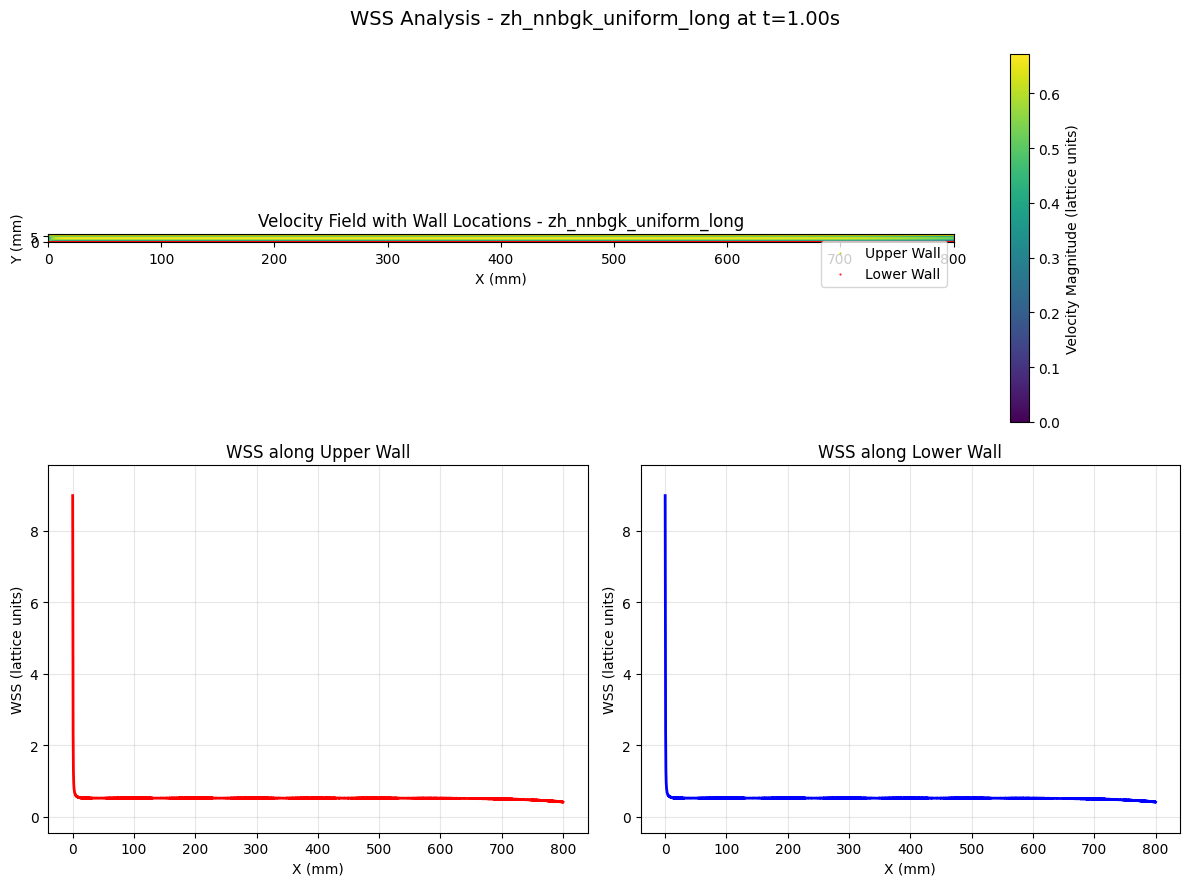


WSS Statistics for zh_nnbgk_uniform_long:
Upper Wall - Mean: 0.514375, Max: 8.978326, Std: 0.166061
Lower Wall - Mean: 0.514375, Max: 8.978327, Std: 0.166061
Overall - Mean: 0.514375, Max: 8.978327

Analyzing zh_nnbgk_blunted_long
Successfully loaded parameters from /home/abdua786/code/uni/3/dissertation/dissertation/visualisation_src/../results/pipe_flow/zh_nnbgk_blunted_long/parameters/pipe_zh_nnbgk_params.json

Loading velocity data for zh_nnbgk_blunted_long...
Found 101 frames, range: 0 to 25000
Loaded u_magnitude data with shape: (101, 86, 10001)
Data loaded in 1.43 seconds

Loading WSS data for zh_nnbgk_blunted_long...
Loaded wss_magnitude data with shape: (101, 86, 10001)
WSS data loaded in 0.77 seconds
✅ Successfully loaded data for zh_nnbgk_blunted_long


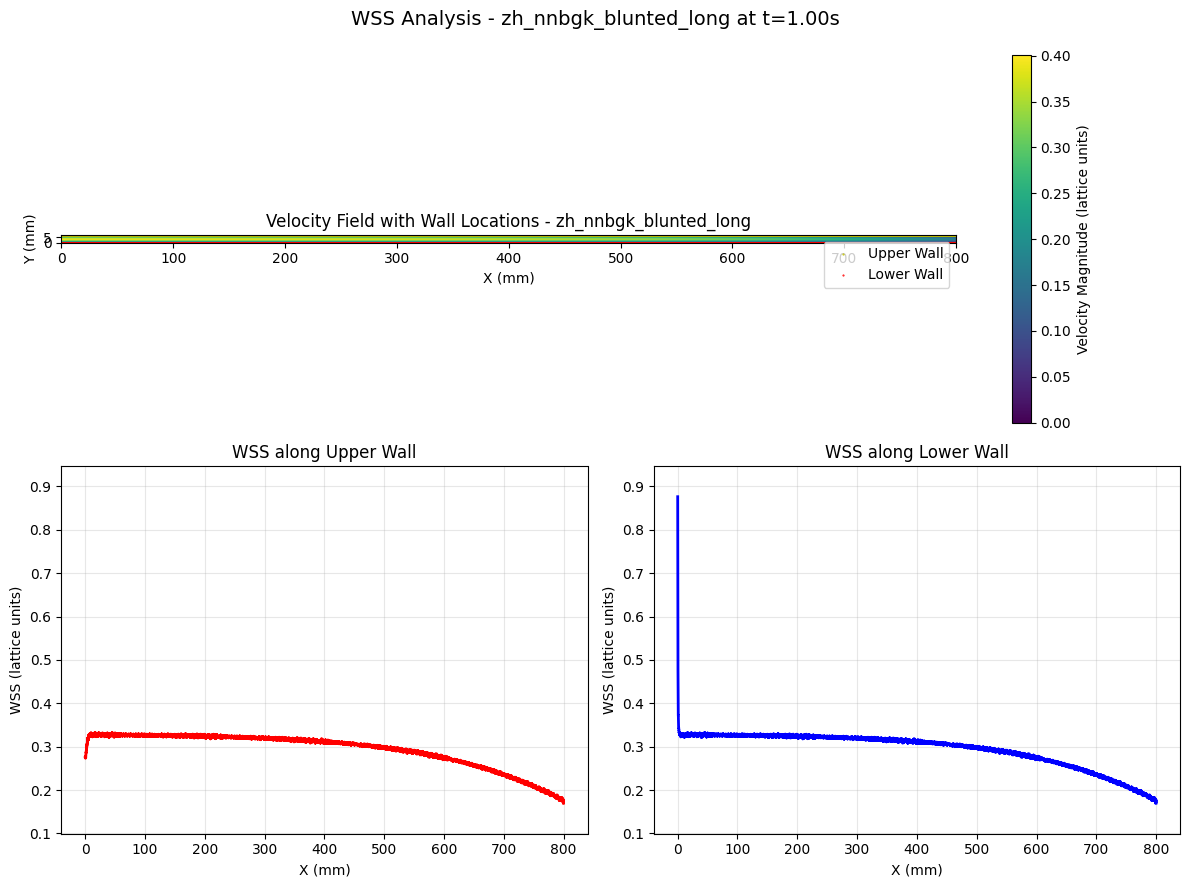


WSS Statistics for zh_nnbgk_blunted_long:
Upper Wall - Mean: 0.293349, Max: 0.332621, Std: 0.040049
Lower Wall - Mean: 0.293842, Max: 0.876337, Std: 0.041425
Overall - Mean: 0.293596, Max: 0.876337

Analyzing zh_nnbgk_poiseuille_long
Successfully loaded parameters from /home/abdua786/code/uni/3/dissertation/dissertation/visualisation_src/../results/pipe_flow/zh_nnbgk_poiseuille_long/parameters/pipe_zh_nnbgk_params.json

Loading velocity data for zh_nnbgk_poiseuille_long...
Found 101 frames, range: 0 to 25000
Loaded u_magnitude data with shape: (101, 86, 10001)
Data loaded in 1.43 seconds

Loading WSS data for zh_nnbgk_poiseuille_long...
Loaded wss_magnitude data with shape: (101, 86, 10001)
WSS data loaded in 0.75 seconds
✅ Successfully loaded data for zh_nnbgk_poiseuille_long


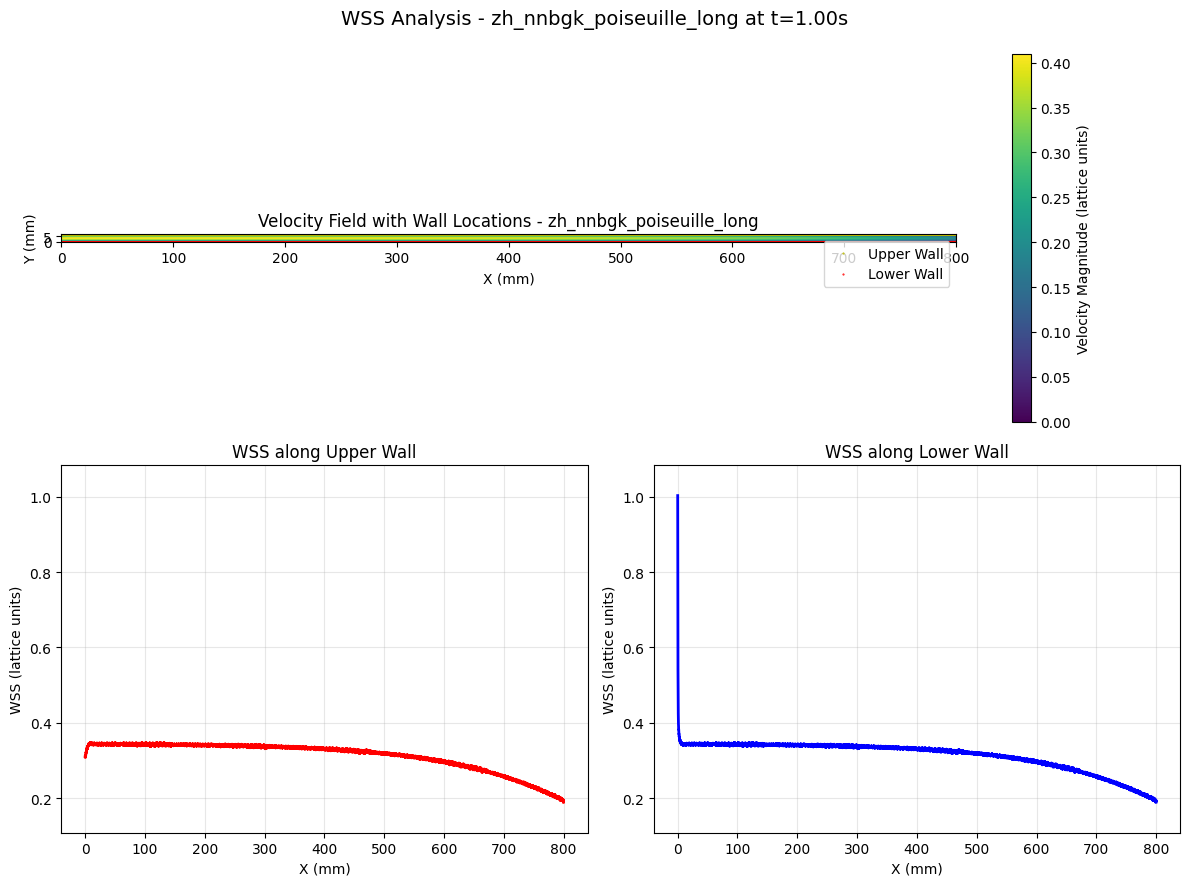


WSS Statistics for zh_nnbgk_poiseuille_long:
Upper Wall - Mean: 0.312362, Max: 0.347865, Std: 0.038656
Lower Wall - Mean: 0.312917, Max: 1.003298, Std: 0.040749
Overall - Mean: 0.312640, Max: 1.003298

WSS ANALYSIS COMPLETE


In [28]:
# Analyze WSS for all long pipe configurations that have processed data
print("="*80)
print("WSS ANALYSIS FOR LONG PIPE CONFIGURATIONS")
print("="*80)

for config in long_pipe_configs:
    config_name = config.name
    print(f"\n{'='*60}")
    print(f"Analyzing {config_name}")
    print(f"{'='*60}")
    
    # Check if processed data exists
    processed_data_dir = config / 'processed_data' / 'raw_fields'
    if not processed_data_dir.exists():
        print(f"❌ No processed data found for {config_name}")
        print(f"   Expected: {processed_data_dir}")
        continue
    
    # Find parameter file
    params_dir = config / 'parameters'
    param_file = None
    if params_dir.exists():
        json_files = list(params_dir.glob('*.json'))
        if json_files:
            param_file = json_files[0]
    
    if param_file is None:
        print(f"⚠️  No parameter file found for {config_name}")
        params = None
    else:
        params = load_params(param_file)
    
    # Load velocity and WSS data
    try:
        velocity_data = load_velocity_data(config, config_name)
        wss_data = load_wss_data(config, config_name)
        
        if velocity_data is not None and wss_data is not None:
            print(f"✅ Successfully loaded data for {config_name}")
            
            # Analyze WSS at t=1.0 seconds
            analyze_pipe_wss(velocity_data, wss_data, params, time=1.0, config_name=config_name)
            
        else:
            print(f"❌ Failed to load complete data for {config_name}")
            
    except Exception as e:
        print(f"❌ Error analyzing {config_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print("WSS ANALYSIS COMPLETE")
print(f"{'='*80}")

## Velocity Profile Analysis for Long Pipe Configurations

Analyze velocity profiles at specific cross-sections and time points for each long pipe configuration, similar to Objective 3.

In [32]:
# Enhanced function to load complete velocity data for profile analysis
def load_complete_velocity_data(sim_folder, sim_name):
    """Load complete velocity data including u_x and u_y components for profile analysis"""
    data_dir = sim_folder / 'processed_data' / 'raw_fields'
    if not data_dir.exists():
        print(f"Data directory not found for {sim_name}: {data_dir}")
        return None
    
    try:
        print(f"\nLoading complete velocity data for {sim_name}...")
        # Load frame mapping
        frame_mapping_file = data_dir / 'frame_mapping.npz'
        if frame_mapping_file.exists():
            frame_mapping = np.load(frame_mapping_file)
            frame_numbers = frame_mapping['frame_numbers']
            frame_indices = frame_mapping['frame_indices']
            print(f"Found {len(frame_numbers)} frames, range: {min(frame_numbers)} to {max(frame_numbers)}")
        else:
            print(f"Frame mapping file not found: {frame_mapping_file}")
            return None
        
        # Load velocity components
        start_time = time.time()
        
        # Load u_x component
        u_x_file = data_dir / 'u_x.npz'
        if u_x_file.exists():
            u_x_data = np.load(u_x_file)['data']
            print(f"Loaded u_x data with shape: {u_x_data.shape}")
        else:
            print(f"u_x data file not found: {u_x_file}")
            u_x_data = None
        
        # Load u_y component
        u_y_file = data_dir / 'u_y.npz'
        if u_y_file.exists():
            u_y_data = np.load(u_y_file)['data']
            print(f"Loaded u_y data with shape: {u_y_data.shape}")
        else:
            print(f"u_y data file not found: {u_y_file}")
            u_y_data = None
        
        # Load u_magnitude
        u_magnitude_file = data_dir / 'u_magnitude.npz'
        if u_magnitude_file.exists():
            u_magnitude_data = np.load(u_magnitude_file)['data']
            print(f"Loaded u_magnitude data with shape: {u_magnitude_data.shape}")
        else:
            print(f"u_magnitude data file not found: {u_magnitude_file}")
            u_magnitude_data = None
        
        load_time = time.time() - start_time
        print(f"Complete velocity data loaded in {load_time:.2f} seconds")
        
        return {
            'frame_numbers': frame_numbers,
            'frame_indices': frame_indices,
            'u_x': u_x_data,
            'u_y': u_y_data,
            'u_magnitude': u_magnitude_data
        }
    
    except Exception as e:
        print(f"Error loading complete velocity data for {sim_name}: {e}")
        return None

In [33]:
def analyze_velocity_profiles(velocity_data, params, config_name, time_points=[0.2, 0.5, 1.0], positions=[0.0, 0.25, 0.5, 0.75, 1.0]):
    """Analyze velocity profiles at specific cross-sections and time points"""
    if velocity_data is None:
        print(f"Missing velocity data for {config_name}")
        return
    
    # Extract frame data
    frame_numbers = velocity_data.get('frame_numbers')
    u_magnitude = velocity_data.get('u_magnitude')
    
    if frame_numbers is None or u_magnitude is None:
        print(f"Missing required data components for {config_name}")
        return
    
    # Get simulation parameters
    if params is not None:
        dt = params['input_parameters'].get('dt', 1e-5)
        dx = params['input_parameters'].get('dx', 2e-5)
        fps = params['input_parameters'].get('fps', 100)
    else:
        # Default values
        dt = 1e-5
        dx = 2e-5
        fps = 100
    
    # Convert velocities to physical units
    vel_scale = dx / dt  # m/s per lattice unit
    
    # Get dimensions
    ny, nx = u_magnitude[0].shape
    
    # Create y coordinate array in physical units (mm)
    y_mm = np.linspace(0, ny * dx * 1000, ny)  # Convert m to mm
    
    print(f"\n{'='*50}")
    print(f"VELOCITY PROFILE ANALYSIS - {config_name}")
    print(f"{'='*50}")
    
    # Analyze for each time point
    for target_time in time_points:
        # Convert time to frame index
        frame_idx = int(target_time * fps)
        
        # Ensure frame_idx is valid
        if frame_idx >= len(u_magnitude):
            frame_idx = len(u_magnitude) - 1
            actual_time = frame_numbers[frame_idx] * dt
            print(f"Time {target_time:.1f}s out of range. Using last available time {actual_time:.2f}s instead.")
        else:
            actual_time = target_time
        
        # Get velocity data for this frame
        frame_u_mag = u_magnitude[frame_idx]
        frame_u_mag_phys = frame_u_mag * vel_scale  # Convert to m/s
        
        # Create plot for this time point
        fig, axes = plt.subplots(1, len(positions), figsize=(20, 6))
        if len(positions) == 1:
            axes = [axes]  # Ensure axes is always a list
        
        # Plot velocity profiles at each position
        for i, pos in enumerate(positions):
            # Calculate x index for this position
            if pos == 0.0:
                x_idx = 1  # Avoid boundary
            elif pos == 1.0:
                x_idx = nx - 2  # Avoid boundary
            else:
                x_idx = int(pos * nx)
            
            # Get velocity profile at this x position
            profile = frame_u_mag_phys[:, x_idx]
            
            # Plot velocity profile
            axes[i].plot(profile, y_mm, 'b-', linewidth=2, label=config_name)
            
            # Add positional labels
            position_label = "Inlet" if pos == 0.0 else "Outlet" if pos == 1.0 else f"{pos*100:.0f}% of Length"
            
            # Customize the plot
            axes[i].set_title(f"Position: {position_label}")
            axes[i].set_xlabel('Velocity (m/s)')
            if i == 0:
                axes[i].set_ylabel('Y Position (mm)')
            axes[i].grid(True, alpha=0.3)
            
            # Add statistics text
            max_vel = profile.max()
            mean_vel = profile[profile > 0].mean() if np.any(profile > 0) else 0
            axes[i].text(0.05, 0.95, f'Max: {max_vel:.4f} m/s\\nMean: {mean_vel:.4f} m/s', 
                        transform=axes[i].transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Set the same velocity range for all plots
        all_profiles = frame_u_mag_phys.flatten()
        v_max = all_profiles.max()
        v_range = v_max
        for ax in axes:
            ax.set_xlim(-0.05*v_range, v_max + 0.05*v_range)
        
        plt.suptitle(f"Velocity Profiles - {config_name} at t≈{actual_time:.2f}s", fontsize=16, y=1.05)
        plt.tight_layout()
        plt.subplots_adjust(top=0.85)
        plt.show()
        
        # Print statistics for this time point
        print(f"\\nTime t={actual_time:.2f}s statistics:")
        for i, pos in enumerate(positions):
            if pos == 0.0:
                x_idx = 1
            elif pos == 1.0:
                x_idx = nx - 2
            else:
                x_idx = int(pos * nx)
            
            profile = frame_u_mag_phys[:, x_idx]
            position_label = "Inlet" if pos == 0.0 else "Outlet" if pos == 1.0 else f"{pos*100:.0f}%"
            max_vel = profile.max()
            mean_vel = profile[profile > 0].mean() if np.any(profile > 0) else 0
            print(f"  {position_label}: Max={max_vel:.4f} m/s, Mean={mean_vel:.4f} m/s")

def compare_velocity_profiles_between_configs(configs_data, time_point=1.0, position=0.5):
    """Compare velocity profiles between different configurations at a specific time and position"""
    if not configs_data:
        print("No configuration data available for comparison")
        return
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    linestyles = ['-', '--', '-.', ':', '-']
    
    for i, (config_name, velocity_data, params) in enumerate(configs_data):
        if velocity_data is None:
            continue
        
        # Get simulation parameters
        if params is not None:
            dt = params['input_parameters'].get('dt', 1e-5)
            dx = params['input_parameters'].get('dx', 2e-5)
            fps = params['input_parameters'].get('fps', 100)
        else:
            dt, dx, fps = 1e-5, 2e-5, 100
        
        # Convert time to frame index
        frame_idx = int(time_point * fps)
        if frame_idx >= len(velocity_data['u_magnitude']):
            frame_idx = len(velocity_data['u_magnitude']) - 1
        
        # Get velocity data
        frame_u_mag = velocity_data['u_magnitude'][frame_idx]
        vel_scale = dx / dt
        frame_u_mag_phys = frame_u_mag * vel_scale
        
        # Get dimensions and position
        ny, nx = frame_u_mag.shape
        y_mm = np.linspace(0, ny * dx * 1000, ny)
        
        if position == 0.0:
            x_idx = 1
        elif position == 1.0:
            x_idx = nx - 2
        else:
            x_idx = int(position * nx)
        
        # Get velocity profile
        profile = frame_u_mag_phys[:, x_idx]
        
        # Plot
        color = colors[i % len(colors)]
        linestyle = linestyles[i % len(linestyles)]
        ax.plot(profile, y_mm, color=color, linestyle=linestyle, linewidth=2, 
                label=config_name)
    
    # Customize plot
    position_label = "Inlet" if position == 0.0 else "Outlet" if position == 1.0 else f"{position*100:.0f}% of Length"
    ax.set_title(f"Velocity Profile Comparison at {position_label} (t={time_point:.1f}s)")
    ax.set_xlabel('Velocity (m/s)')
    ax.set_ylabel('Y Position (mm)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

VELOCITY PROFILE ANALYSIS FOR LONG PIPE CONFIGURATIONS (t=1.0s)

Loading velocity data for zh_nnbgk_uniform_long
Successfully loaded parameters from /home/abdua786/code/uni/3/dissertation/dissertation/visualisation_src/../results/pipe_flow/zh_nnbgk_uniform_long/parameters/pipe_zh_nnbgk_params.json

Loading complete velocity data for zh_nnbgk_uniform_long...
Found 101 frames, range: 0 to 25000


Loaded u_x data with shape: (101, 86, 10001)
Loaded u_y data with shape: (101, 86, 10001)
Loaded u_magnitude data with shape: (101, 86, 10001)
Complete velocity data loaded in 4.12 seconds
✅ Successfully loaded velocity data for zh_nnbgk_uniform_long

Loading velocity data for zh_nnbgk_blunted_long
Successfully loaded parameters from /home/abdua786/code/uni/3/dissertation/dissertation/visualisation_src/../results/pipe_flow/zh_nnbgk_blunted_long/parameters/pipe_zh_nnbgk_params.json

Loading complete velocity data for zh_nnbgk_blunted_long...
Found 101 frames, range: 0 to 25000
Loaded u_x data with shape: (101, 86, 10001)
Loaded u_y data with shape: (101, 86, 10001)
Loaded u_magnitude data with shape: (101, 86, 10001)
Complete velocity data loaded in 4.26 seconds
✅ Successfully loaded velocity data for zh_nnbgk_blunted_long

Loading velocity data for zh_nnbgk_poiseuille_long
Successfully loaded parameters from /home/abdua786/code/uni/3/dissertation/dissertation/visualisation_src/../resul

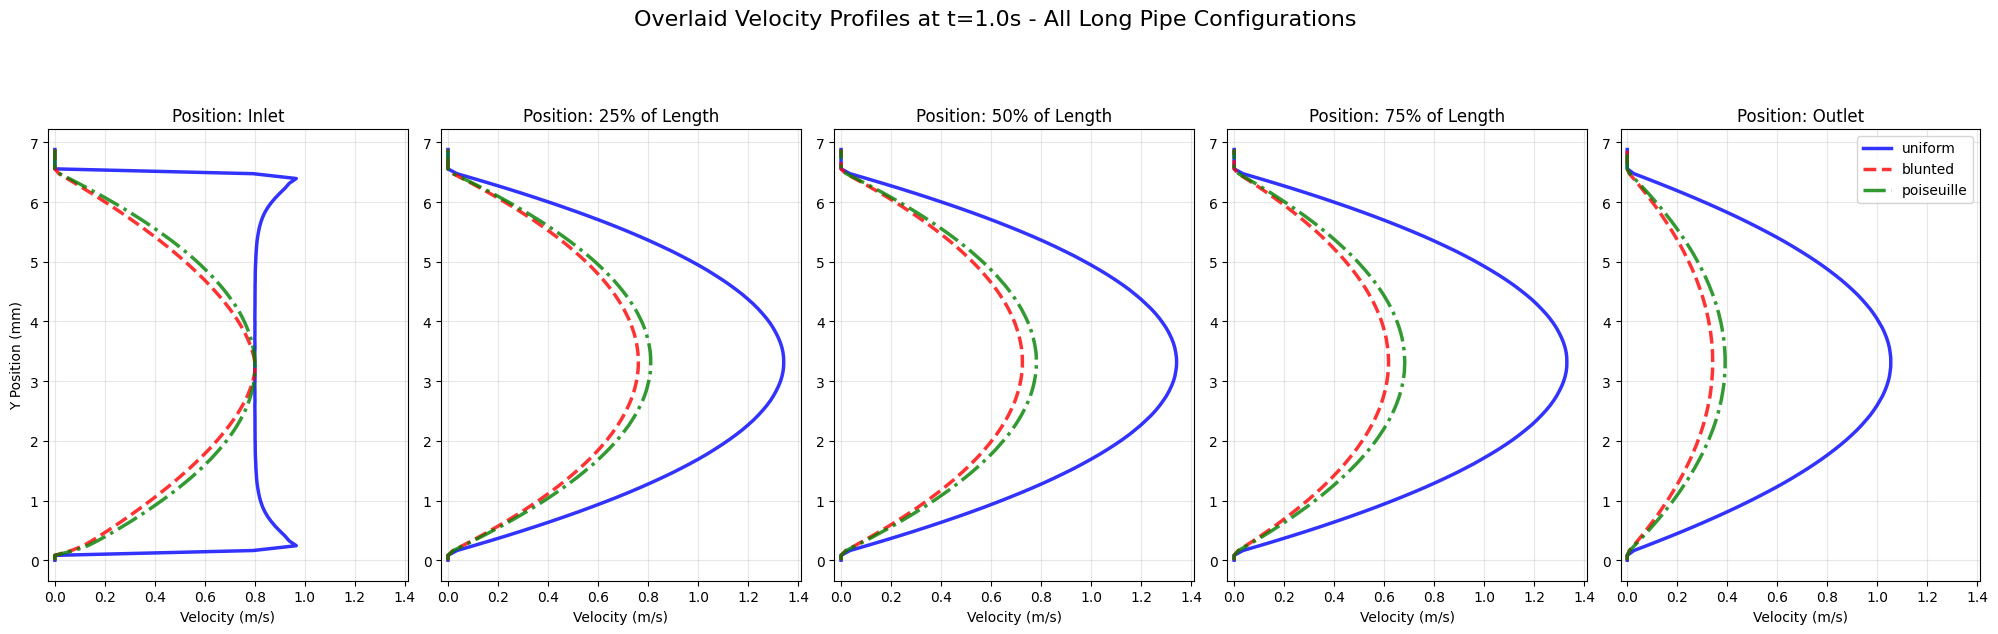


Comparative Statistics at t=1.0s:
------------------------------------------------------------

Inlet:
  uniform        : Max=0.9656 m/s, Mean=0.8226 m/s
  blunted        : Max=0.8011 m/s, Mean=0.5159 m/s
  poiseuille     : Max=0.8010 m/s, Mean=0.5461 m/s

25%:
  uniform        : Max=1.3429 m/s, Mean=0.8989 m/s
  blunted        : Max=0.7615 m/s, Mean=0.5086 m/s
  poiseuille     : Max=0.8110 m/s, Mean=0.5418 m/s

50%:
  uniform        : Max=1.3422 m/s, Mean=0.8985 m/s
  blunted        : Max=0.7253 m/s, Mean=0.4843 m/s
  poiseuille     : Max=0.7812 m/s, Mean=0.5218 m/s

75%:
  uniform        : Max=1.3308 m/s, Mean=0.8906 m/s
  blunted        : Max=0.6177 m/s, Mean=0.4119 m/s
  poiseuille     : Max=0.6826 m/s, Mean=0.4552 m/s

Outlet:
  uniform        : Max=1.0541 m/s, Mean=0.7001 m/s
  blunted        : Max=0.3416 m/s, Mean=0.2271 m/s
  poiseuille     : Max=0.3915 m/s, Mean=0.2603 m/s


In [34]:
# Perform velocity profile analysis for all long pipe configurations
print("="*80)
print("VELOCITY PROFILE ANALYSIS FOR LONG PIPE CONFIGURATIONS (t=1.0s)")
print("="*80)

# Store data for comparison
configs_for_comparison = []

for config in long_pipe_configs:
    config_name = config.name
    print(f"\n{'='*60}")
    print(f"Loading velocity data for {config_name}")
    print(f"{'='*60}")
    
    # Check if processed data exists
    processed_data_dir = config / 'processed_data' / 'raw_fields'
    if not processed_data_dir.exists():
        print(f"❌ No processed data found for {config_name}")
        continue
    
    # Find parameter file
    params_dir = config / 'parameters'
    param_file = None
    if params_dir.exists():
        json_files = list(params_dir.glob('*.json'))
        if json_files:
            param_file = json_files[0]
    
    if param_file is None:
        print(f"⚠️  No parameter file found for {config_name}")
        params = None
    else:
        params = load_params(param_file)
    
    # Load complete velocity data
    try:
        velocity_data = load_complete_velocity_data(config, config_name)
        
        if velocity_data is not None:
            print(f"✅ Successfully loaded velocity data for {config_name}")
            
            # Store for comparison
            configs_for_comparison.append((config_name, velocity_data, params))
            
        else:
            print(f"❌ Failed to load velocity data for {config_name}")
            
    except Exception as e:
        print(f"❌ Error loading velocity data for {config_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print("DATA LOADING COMPLETE")
print(f"{'='*80}")

# Create overlaid velocity profile plots at t=1.0s
if len(configs_for_comparison) >= 1:
    print(f"\n{'='*80}")
    print("OVERLAID VELOCITY PROFILE COMPARISON AT t=1.0s")
    print(f"{'='*80}")
    
    # Define positions to analyze
    positions = [0.0, 0.25, 0.5, 0.75, 1.0]  # positions along pipe length
    time_point = 1.0  # Only analyze at t=1.0s
    
    # Create overlaid plot for all positions
    fig, axes = plt.subplots(1, len(positions), figsize=(20, 6))
    if len(positions) == 1:
        axes = [axes]
    
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    linestyles = ['-', '--', '-.', ':', '-']
    
    for i, pos in enumerate(positions):
        position_label = "Inlet" if pos == 0.0 else "Outlet" if pos == 1.0 else f"{pos*100:.0f}% of Length"
        
        # Plot each configuration on the same subplot
        for j, (config_name, velocity_data, params) in enumerate(configs_for_comparison):
            # Get simulation parameters
            if params is not None:
                dt = params['input_parameters'].get('dt', 1e-5)
                dx = params['input_parameters'].get('dx', 2e-5)
                fps = params['input_parameters'].get('fps', 100)
            else:
                dt, dx, fps = 1e-5, 2e-5, 100
            
            # Convert time to frame index
            frame_idx = int(time_point * fps)
            if frame_idx >= len(velocity_data['u_magnitude']):
                frame_idx = len(velocity_data['u_magnitude']) - 1
            
            # Get velocity data
            frame_u_mag = velocity_data['u_magnitude'][frame_idx]
            vel_scale = dx / dt
            frame_u_mag_phys = frame_u_mag * vel_scale
            
            # Get dimensions and position
            ny, nx = frame_u_mag.shape
            y_mm = np.linspace(0, ny * dx * 1000, ny)
            
            if pos == 0.0:
                x_idx = 1
            elif pos == 1.0:
                x_idx = nx - 2
            else:
                x_idx = int(pos * nx)
            
            # Get velocity profile
            profile = frame_u_mag_phys[:, x_idx]
            
            # Plot with different colors and styles
            color = colors[j % len(colors)]
            linestyle = linestyles[j % len(linestyles)]
            
            # Create simplified config name for legend
            simple_name = config_name.replace('zh_nnbgk_', '').replace('_long', '')
            
            axes[i].plot(profile, y_mm, color=color, linestyle=linestyle, linewidth=2.5, 
                        label=simple_name, alpha=0.8)
        
        # Customize each subplot
        axes[i].set_title(f"Position: {position_label}", fontsize=12)
        axes[i].set_xlabel('Velocity (m/s)', fontsize=10)
        if i == 0:
            axes[i].set_ylabel('Y Position (mm)', fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        # Add legend only to the last subplot
        if i == len(positions) - 1:
            axes[i].legend(fontsize=10)
    
    # Set the same velocity range for all plots
    all_max_velocities = []
    for config_name, velocity_data, params in configs_for_comparison:
        if params is not None:
            dt = params['input_parameters'].get('dt', 1e-5)
            dx = params['input_parameters'].get('dx', 2e-5)
            fps = params['input_parameters'].get('fps', 100)
        else:
            dt, dx, fps = 1e-5, 2e-5, 100
        
        frame_idx = int(time_point * fps)
        if frame_idx >= len(velocity_data['u_magnitude']):
            frame_idx = len(velocity_data['u_magnitude']) - 1
        
        frame_u_mag = velocity_data['u_magnitude'][frame_idx]
        vel_scale = dx / dt
        frame_u_mag_phys = frame_u_mag * vel_scale
        all_max_velocities.append(frame_u_mag_phys.max())
    
    v_max = max(all_max_velocities)
    for ax in axes:
        ax.set_xlim(-0.02*v_max, v_max + 0.05*v_max)
    
    plt.suptitle(f"Overlaid Velocity Profiles at t={time_point:.1f}s - All Long Pipe Configurations", 
                 fontsize=16, y=1.05)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
    # Print comparative statistics
    print(f"\nComparative Statistics at t={time_point:.1f}s:")
    print("-" * 60)
    for pos in positions:
        position_label = "Inlet" if pos == 0.0 else "Outlet" if pos == 1.0 else f"{pos*100:.0f}%"
        print(f"\n{position_label}:")
        
        for config_name, velocity_data, params in configs_for_comparison:
            if params is not None:
                dt = params['input_parameters'].get('dt', 1e-5)
                dx = params['input_parameters'].get('dx', 2e-5)
                fps = params['input_parameters'].get('fps', 100)
            else:
                dt, dx, fps = 1e-5, 2e-5, 100
            
            frame_idx = int(time_point * fps)
            if frame_idx >= len(velocity_data['u_magnitude']):
                frame_idx = len(velocity_data['u_magnitude']) - 1
            
            frame_u_mag = velocity_data['u_magnitude'][frame_idx]
            vel_scale = dx / dt
            frame_u_mag_phys = frame_u_mag * vel_scale
            ny, nx = frame_u_mag.shape
            
            if pos == 0.0:
                x_idx = 1
            elif pos == 1.0:
                x_idx = nx - 2
            else:
                x_idx = int(pos * nx)
            
            profile = frame_u_mag_phys[:, x_idx]
            max_vel = profile.max()
            mean_vel = profile[profile > 0].mean() if np.any(profile > 0) else 0
            
            simple_name = config_name.replace('zh_nnbgk_', '').replace('_long', '')
            print(f"  {simple_name:15}: Max={max_vel:.4f} m/s, Mean={mean_vel:.4f} m/s")

else:
    print(f"\nNote: Only {len(configs_for_comparison)} configuration(s) available.")